In [1]:
from google.colab import files
import io

uploaded = files.upload()


Saving train.csv to train.csv


**Phase 1**

---



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded!")

All libraries loaded!


In [3]:
df = pd.read_csv('train.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()


Shape: (1460, 81)

First 5 rows:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
# Calculate missing percentage per column
missing = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_percent': (df.isnull().sum() / len(df)) * 100
})

# Only show columns that have missing values
missing = missing[missing['missing_count'] > 0].sort_values('missing_percent', ascending=False)

print(f"Total columns with missing values: {len(missing)}")
print("\n", missing)

Total columns with missing values: 19

               missing_count  missing_percent
PoolQC                 1453        99.520548
MiscFeature            1406        96.301370
Alley                  1369        93.767123
Fence                  1179        80.753425
MasVnrType              872        59.726027
FireplaceQu             690        47.260274
LotFrontage             259        17.739726
GarageType               81         5.547945
GarageYrBlt              81         5.547945
GarageFinish             81         5.547945
GarageQual               81         5.547945
GarageCond               81         5.547945
BsmtExposure             38         2.602740
BsmtFinType2             38         2.602740
BsmtQual                 37         2.534247
BsmtCond                 37         2.534247
BsmtFinType1             37         2.534247
MasVnrArea                8         0.547945
Electrical                1         0.068493


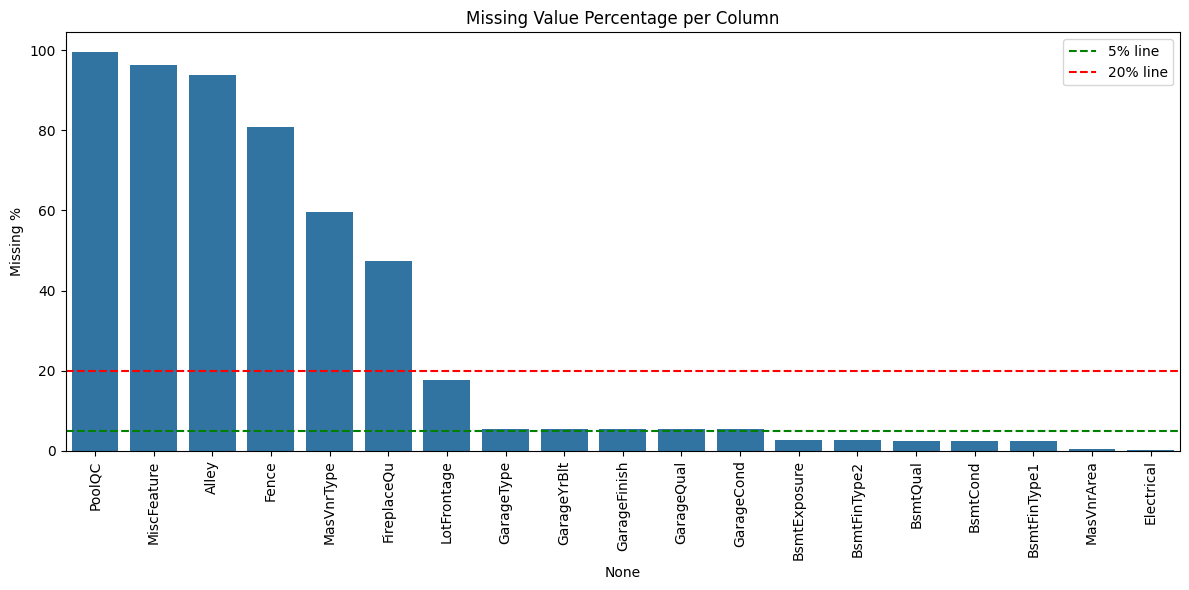

In [5]:
plt.figure(figsize=(12, 6))
sns.barplot(x=missing.index, y=missing['missing_percent'])
plt.xticks(rotation=90)
plt.title('Missing Value Percentage per Column')
plt.ylabel('Missing %')
plt.axhline(y=5, color='green', linestyle='--', label='5% line')
plt.axhline(y=20, color='red', linestyle='--', label='20% line')
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
# GROUP 1: >20% missing → Drop columns entirely
cols_to_drop = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType', 'FireplaceQu']
df.drop(columns=cols_to_drop, inplace=True)
print(f"Dropped {len(cols_to_drop)} columns with >20% missing")

# GROUP 2: 5-20% missing → Median imputation (numeric)
cols_median = ['LotFrontage', 'GarageYrBlt']
for col in cols_median:
    df[col].fillna(df[col].median(), inplace=True)

# GROUP 3: Categorical Garage columns → Mode imputation
cols_mode = ['GarageType', 'GarageFinish', 'GarageQual', 'GarageCond']
for col in cols_mode:
    df[col].fillna(df[col].mode()[0], inplace=True)

# GROUP 4: <5% missing → Median/Mode
df['MasVnrArea'].fillna(df['MasVnrArea'].median(), inplace=True)
df['Electrical'].fillna(df['Electrical'].mode()[0], inplace=True)

# Bsmt columns → Mode
bsmt_cols = ['BsmtExposure', 'BsmtFinType2', 'BsmtQual', 'BsmtCond', 'BsmtFinType1']
for col in bsmt_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Verify no missing values remain
print(f"\nRemaining missing values: {df.isnull().sum().sum()}")
print(f"Dataset shape after cleaning: {df.shape}")

Dropped 6 columns with >20% missing

Remaining missing values: 0
Dataset shape after cleaning: (1460, 75)


**Phase 2**

---



In [7]:
# Numeric columns only (excluding target variable)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('SalePrice')  # protect target variable

print("Applying IQR Winsorization...")

outlier_report = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count outliers before
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]

    if outliers > 0:
        outlier_report[col] = outliers
        # Winsorize — cap values at boundaries (preserve row count)
        df[col] = np.clip(df[col], lower_bound, upper_bound)

print(f"Columns with outliers fixed: {len(outlier_report)}")
print(f"Dataset shape (unchanged): {df.shape}")
print("\nOutliers found per column:")
for col, count in sorted(outlier_report.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f"  {col}: {count} outliers")

Applying IQR Winsorization...
Columns with outliers fixed: 31
Dataset shape (unchanged): (1460, 75)

Outliers found per column:
  EnclosedPorch: 208 outliers
  BsmtFinSF2: 167 outliers
  OverallCond: 125 outliers
  ScreenPorch: 116 outliers
  LotFrontage: 106 outliers
  MSSubClass: 103 outliers
  MasVnrArea: 98 outliers
  BsmtHalfBath: 82 outliers
  OpenPorchSF: 77 outliers
  LotArea: 69 outliers


In [8]:
# Feature 1: House age when sold
df['house_age'] = df['YrSold'] - df['YearBuilt']

# Feature 2: Total bathrooms
df['total_bathrooms'] = (df['FullBath'] +
                         df['BsmtFullBath'] +
                         (df['HalfBath'] * 0.5) +
                         (df['BsmtHalfBath'] * 0.5))

# Feature 3: Total living area
df['total_area'] = df['GrLivArea'] + df['TotalBsmtSF']

# Feature 4 (bonus): Price per sqft of living area
df['quality_score'] = df['OverallQual'] * df['OverallCond']

print("New features created:")
print(df[['house_age', 'total_bathrooms', 'total_area', 'quality_score']].describe())
print(f"\nFinal dataset shape: {df.shape}")

New features created:
         house_age  total_bathrooms   total_area  quality_score
count  1460.000000      1460.000000  1460.000000    1460.000000
mean     36.516438         2.181507  2553.990668      33.641096
std      30.155305         0.791447   738.238038       8.466093
min       0.000000         1.000000   376.000000       7.000000
25%       8.000000         1.500000  2014.000000      30.000000
50%      35.000000         2.000000  2479.000000      35.000000
75%      54.000000         2.500000  3008.500000      40.000000
max     125.000000         5.500000  4799.625000      75.000000

Final dataset shape: (1460, 79)


In [9]:
# Save cleaned dataset
df.to_csv('cleaned_train.csv', index=False)
print("Cleaned dataset saved!")
print(f"Final shape: {df.shape}")

Cleaned dataset saved!
Final shape: (1460, 79)


In [10]:
print("=" * 50)
print("PROJECT 1 - PIPELINE SUMMARY REPORT")
print("=" * 50)

print("\n PHASE 1: INPUT - Missing Values")
print(f"  Columns dropped (>20% missing): 6")
print(f"  Columns imputed with median: 2")
print(f"  Columns imputed with mode: 9")
print(f"  Remaining missing values: 0")

print("\n PHASE 2: PROCESS - Outliers & Features")
print(f"  Columns with outliers fixed: 31")
print(f"  Method used: IQR Winsorization (numpy.clip)")
print(f"  New features engineered: 4")
print(f"    - house_age")
print(f"    - total_bathrooms")
print(f"    - total_area")
print(f"    - quality_score")

print("\n PHASE 3: OUTPUT")
print(f"  Original shape: (1460, 81)")
print(f"  Final shape: (1460, 79)")
print(f"  Dataset saved: cleaned_train.csv")
print("=" * 50)
print("Pipeline Complete!")

PROJECT 1 - PIPELINE SUMMARY REPORT

 PHASE 1: INPUT - Missing Values
  Columns dropped (>20% missing): 6
  Columns imputed with median: 2
  Columns imputed with mode: 9
  Remaining missing values: 0

 PHASE 2: PROCESS - Outliers & Features
  Columns with outliers fixed: 31
  Method used: IQR Winsorization (numpy.clip)
  New features engineered: 4
    - house_age
    - total_bathrooms
    - total_area
    - quality_score

 PHASE 3: OUTPUT
  Original shape: (1460, 81)
  Final shape: (1460, 79)
  Dataset saved: cleaned_train.csv
Pipeline Complete!
